In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import SparsePCA
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore', category = FutureWarning)

# Sub-task 2: Dimensionality Reduction 

###  Use scikit learn’s implementation of sparse PCA to fit a model with two components to the raw data. Sparse PCA is a version of PCA which attempts to find sparse components. The idea is similar to that discussed for factor analysis. Sparsity is controlled by a parameter alpha. For this task, set alpha to 5. Print out the components found by sparse PCA. Now scale the data so that it has mean 0 and variance 1 (you may wish to use scikit learn’s Standard Scaler). Similarly to above, use sparse PCA to fit a model with two components to the scaled data and print out the resulting components. State whether you see a significant difference between the two results, explaining your observation with reference to the properties of the dataset and of PCA. If there is a significant difference between your results state which of the two results is most likely to capture the relationships between the variables. For the result that you think is most likely to capture these relationships, discuss whether or not it supports the potential latent variable model we discussed in lectures.

In [2]:
df2 = pd.read_csv('cars_reduced.csv', names = ['retail price', 'dealer price', 'wheel base', 'length'], sep = ',')
df2 = df2.astype('Float32')
df2.head(3)

,retail price,dealer price,wheel base,length
0,43755.0,39014.0,115.0,197.0
1,46100.0,41100.0,115.0,197.0
2,36945.0,33337.0,106.0,189.0


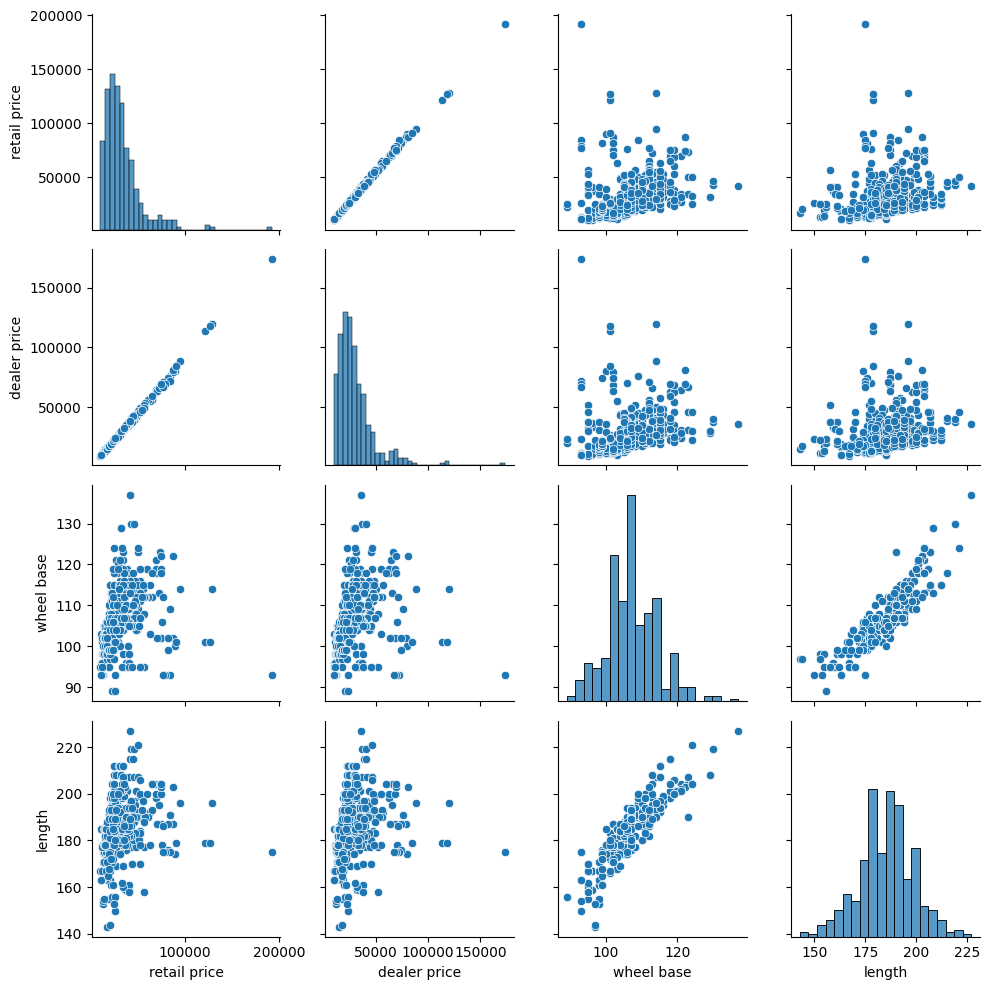

Correlation matrix:

              retail price  dealer price  wheel base    length
retail price      1.000000      0.999150    0.209713  0.214889
dealer price      0.999150      1.000000    0.209066  0.211834
wheel base        0.209713      0.209066    1.000000  0.869250
length            0.214889      0.211834    0.869250  1.000000


In [3]:
# It could be seen that there is a strong pair waise correlation between features.
# By looking at the plot, we can see two issues: 1- the range of the data between features is not the same and very different
# 2- there are some outliers in the data which can effect the PCA.
#  We only address the first issue by using the StandardScaler() function.
sns.pairplot(df2)
plt.tight_layout()
plt.show()
print('Correlation matrix:\n')
print(df2.corr())

In [4]:
# Scale the data
ss = StandardScaler()
df2_scaled = ss.fit_transform(df2)
df2_scaled = pd.DataFrame(df2_scaled, columns = ['retail price', 'dealer price', 'wheel base', 'length'])


In [5]:
# 1- Raw data
pca_raw = SparsePCA(n_components=2, alpha=5, random_state=71)
df_pca_raw = pd.DataFrame(pca_raw.fit_transform(df2), columns=['PC1', 'PC2'])
b4pca = df_pca_raw.describe()
print(b4pca)
# 2- Scaled data
pca_scaled = SparsePCA(n_components=2, alpha=5, random_state=71)
df_pca_sc = pd.DataFrame(pca_scaled.fit_transform(df2_scaled), columns=['PC1', 'PC2'])
af3pca = df_pca_sc.describe()
print(14 * '----')
print(af3pca)

                PC1           PC2
count  4.020000e+02  4.020000e+02
mean   1.737542e-12  4.298607e-13
std    2.643940e+04  5.439408e+02
min   -3.064566e+04 -3.209165e+03
25%   -1.665596e+04 -1.800114e+02
50%   -6.451086e+03  2.503541e+01
75%    8.774431e+03  1.701791e+02
max    2.118826e+05  2.161773e+03
--------------------------------------------------------
              PC1           PC2
count  402.000000  4.020000e+02
mean     0.000000  8.837596e-18
std      1.401658  1.355355e+00
min     -1.623247 -3.317121e+00
25%     -0.881068 -8.051634e-01
50%     -0.341948 -8.357757e-02
75%      0.464947  8.447323e-01
max     11.225152  5.102200e+00


## Plotting the result

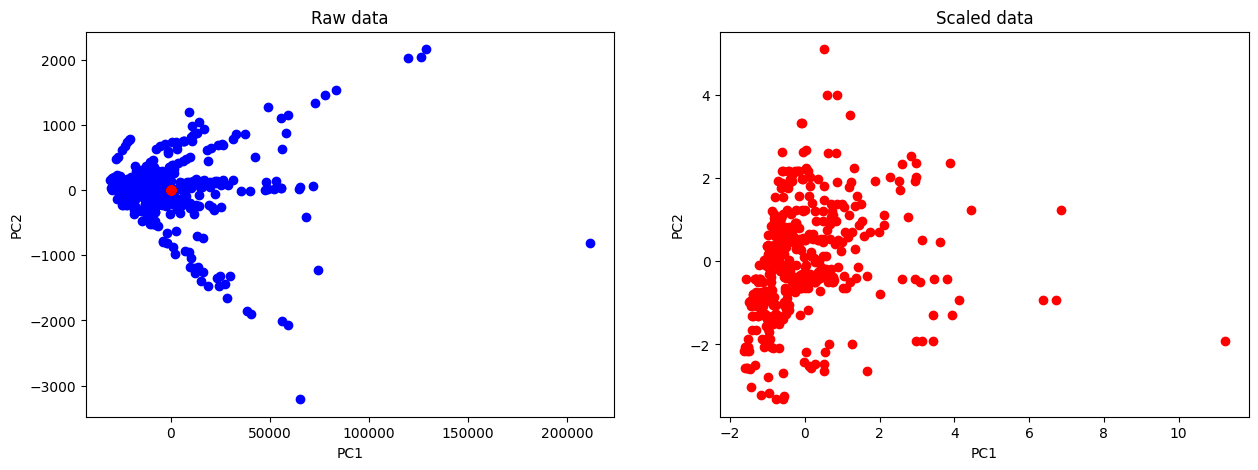

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 5))
ax1.scatter(df_pca_raw['PC1'], df_pca_raw['PC2'], c = 'blue')
ax1.scatter(df_pca_sc['PC1'], df_pca_sc['PC2'], c = 'red') # To show the effect of removing feature scales
ax2.scatter(df_pca_sc['PC1'], df_pca_sc['PC2'], c = 'red')
ax1.set_title('Raw data')
ax2.set_title('Scaled data')
ax1.set_xlabel('PC1')
ax2.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax2.set_ylabel('PC2')
plt.show() 
# By scaling the data before applying SparsePCA, the influence of different feature scales was removed.
# Therefore, all features contribute equally to the components.

Raw data components:
 [[ 7.40925594e-01  6.71587114e-01  4.70385250e-05  9.80024955e-05]
 [-6.40917299e-01  7.67608812e-01  0.00000000e+00 -1.31419263e-03]]


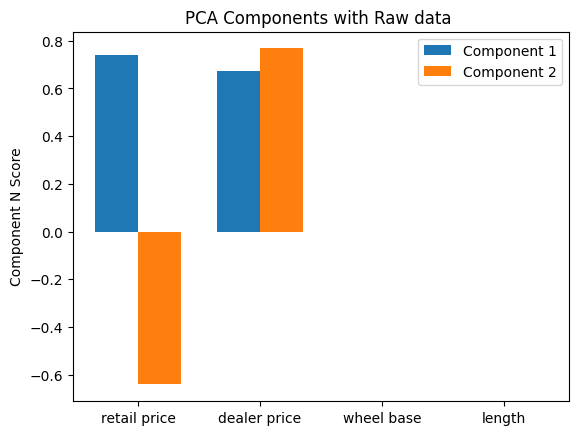

--------------------------------
Scaling & SparsePCA:
Scaled data components:
 [[0.70710678 0.70710678 0.         0.        ]
 [0.         0.         0.70711058 0.70710298]]


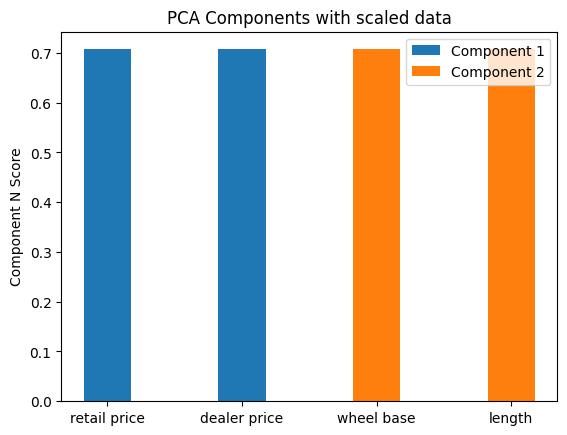

In [7]:
print("Raw data components:\n", pca_raw.components_)
x, width = np.arange(len(df2.columns)), 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, pca_raw.components_[0], width, label='Component 1')
ax.bar(x + width/2, pca_raw.components_[1], width, label='Component 2')

ax.set_xticks(x)
ax.set_xticklabels(df2.columns)
ax.set_ylabel('Component N Score')
ax.set_title('PCA Components with Raw data ')
ax.legend()
plt.show()

print(8 * '----')

print('Scaling & SparsePCA:')
print("Scaled data components:\n", pca_scaled.components_)
x = np.arange(len(df2.columns))

fig, ax = plt.subplots()
ax.bar(x, pca_scaled.components_[0], width, label='Component 1')
ax.bar(x, pca_scaled.components_[1], width, label='Component 2')

ax.set_xticks(x)
ax.set_xticklabels(df2.columns)
ax.set_ylabel('Component N Score')
ax.set_title('PCA Components with scaled data')
ax.legend()
plt.show()

# SUMMARY:

## PCA Sensitivity to unscaled data:
Due to the scale difference in **raw data** (first plot), components are skewed toward high-magnitude features (retail & dealer). This results in 
 **Near-zero loadings** for (length variables): ([0.74, 0.67, **0.00005**, **0.0001**]), which are result of unscaled data.  
- **Obscured relationships**: Components fail to isolate distinct feature groups, as seen in the overlapping raw data projection.
## Effect of Standardization:
After standardization, the **shift from high to low** feature scales (plot 2, blue to red) **reduces** the dominance of **high-magnitude features**, revealing two distinct latent factors that were obscured in the raw data by correlation(plot 1). As seen in the third and fourth plots, scaling enables SparsePCA to distinctly capture related features: *price* (retail and dealer) in one component, and *size* (wheel and length) in another. This improvement results from feature scaling, which ensures that all features contribute equally to the component formation, allowing SparsePCA's sparsity constraint to more effectively isolate interpretable patterns.

## Refrences: 
1- Importance of Feature Scaling [Web page](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_scaling_importance.html)

2- Sparse PCA [Web page](https://en.wikipedia.org/wiki/Sparse_PCA) | PCA [Web page](https://en.wikipedia.org/wiki/Principal_component_analysis)

3- Unlocking Data Insights with Principal Component Analysis (PCA) [Web page](https://www.linkedin.com/pulse/unlocking-data-insights-principal-component-analysis-pca-ashtekar--mc2hf)